# Figure 8: gridness and irrep selectivity on $C_{21}^2\rtimes C_6$

This notebook rebuilds the main figure and appendix examples from the original Giocomo
explorer. It uses the `DiscreteSE2Group` implementation in your current `src/groups` folder,
fixes spike alignment, and gives the scatter highlights and example panels one shared
cell-selection table. **No experimental scores or figures have been regenerated in this
delivered copy:** the large MATLAB recording was not attached. All outputs below are
generated by running the notebook against your recording.

### Run it

1. Save this notebook inside **`notebooks/neural_data/Giocomo`**, beside
   `Freely_moving_data_without_inertial_sensor.mat`, and start the kernel there.
2. Check `DATA_DIR` in the first code cell. The repository root is found by walking upwards
   until `src/groups/znxzn_cm.py` exists; no old `group-agf` sibling folder is needed.
3. **Restart Kernel and Run All.** The first run computes per-cell scores; later runs reuse
   `figure8/cache/<run_id>/`. Changes to analysis parameters or the group source choose a new
   cache. If you edit an analysis function, also change `PIPELINE_VERSION` or set `USE_CACHE=False`.
4. Use **`figure8/figure8_irrep_selectivity_m6.pdf`** as a **full-width figure** in the paper.
   It places a large joint score plot above a two-by-two block of **spike map, autocorrelation,
   and irrep power** examples, arranged to match the scatter quadrants. Use the whole manuscript
   width; the expanded figure is intended to have more vertical space than the old narrow layout.
   `figure8/panels/` contains just **the scatter with marginals and legend, and one complete row
   per main example**. **All figures are saved as PDF only.** The component table identifies each
   export and cell. Adjust `MAIN_FIGSIZE`, `SCATTER_LABEL_SIZE` (default **15 pt**), and
   `SCATTER_TICK_SIZE` (default **10 pt**) in the first code cell. Re-running plotting does not
   recompute scores. The five component PDFs also allow the overview and example rows to be
   placed separately if manuscript space is limited.

Dependencies: Python 3.10+, NumPy, SciPy, h5py, Matplotlib, Jupyter/IPython; tqdm is optional.
If needed, install these in your notebook environment with
`%pip install numpy scipy h5py matplotlib tqdm`.

### Analysis and display choices in this revision

| Item | This revision |
|---|---|
| Group | **$n=21$, $m=6$**; 2,646 group elements, 82 complex irreps |
| Score input | Raw, unsmoothed position × **movement-direction** rate tensor |
| Included irreps | **`min_irrep_index=15`**, inclusive: indices 15–81 (67 irreps, all dimension six) |
| Score | $\mathrm{IS}=\log K-H(p)$, natural logarithms, in **nats** |
| Cutoffs | 95th percentiles among cells having both scores; descriptive, not null-model significance |
| Preferred cells | Original indices **462, 124, 94, 78**, subject to their recomputed groups |
| Gridness | Fixed annulus and **21 × 21** spatial grid; Gaussian smoothing σ = 1 bin |
| Main examples | Spike map + autocorrelation + power distribution for each of four cells |
| Scatter axes | **x: Irrep selectivity (nats); y: Gridness score** |
| Appendix details | Four cells per group; one shared power-axis range across all displayed cells |
| Figure exports | PDF only; main components are one joint plot and four complete cell rows |

**Read before using the methods text.** The old notebook already ran with $m=6$; stale prose
and imports suggested otherwise. Its angular variable was *movement direction*, not measured
head direction. `min_irrep_index=15` is an enumeration cutoff, **not a low-frequency filter**.
For $n=21$, it removes the six one-dimensional irreps, three two-dimensional irreps, and the first
six six-dimensional irreps. It therefore excludes all smaller irreps, but is not equivalent to
selecting *all* six-dimensional irreps, nor has it been validated as a finite-sample bias correction.
The historical option name `irrep_selection="legacy_index"` simply means to apply the configured
index cutoff (now 15). `irrep_selection="all_nontrivial"` is an explicit alternative and the
all-nontrivial score is exported as a diagnostic regardless.
The existing Cartesian-bin → triangular-lattice coordinate assignment is retained and described
in the methods. It is not an exact implementation of Euclidean 60° rotations of rectangular bins.
These scientific choices should remain explicit in the submitted paper.

Corrections that can change scores: spikes are aligned before filtering behaviour, out-of-range
spikes and tracking gaps are excluded, and occupancy uses actual tracking intervals. Old score
values, thresholds, and example-group membership should therefore not be copied into the new figure.
**The new $n=21$ and cutoff 15 settings also require recomputation.** The cache identity includes
both values, so results from $n=20$ or cutoff 25 cannot be silently reused. Preferred examples are
checked again against the new percentile groups. All four main spectra share a vertical scale.
This layout revision reuses the existing $n=21$, cutoff-15 cache; swapping the scatter axes
does not change the scores, cutoffs, or cell groups. Large appendix overview sweeps are optional:
set `EXPORT_OVERVIEW_GALLERIES=True` if needed. The compact diagnostic pages are always generated.

## 1. Paths, analysis settings, and figure settings

The defaults match your folder screenshot. All user-facing controls are collected here.

In [38]:
import sys
import csv
import json
import hashlib
import warnings
from io import BytesIO
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime, timezone

import h5py
import numpy as np
import scipy
import scipy.io
from scipy.ndimage import gaussian_filter, rotate
from scipy.signal import correlate2d
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

# Run from notebooks/neural_data/Giocomo, alongside the MATLAB file.
DATA_DIR = Path.cwd()
FILE_PATH = DATA_DIR / "Freely_moving_data_without_inertial_sensor.mat"
OUTPUT_DIR = DATA_DIR / "figure8"
PROJECT_ROOT_OVERRIDE = None  # e.g. Path('/absolute/path/to/your/repository')

@dataclass(frozen=True)
class AnalysisConfig:
    n_space: int = 21
    m_dir: int = 6
    grid_n_bins: int = 21
    grid_smooth_sigma: float = 1.0  # spatial bins; gridness only
    min_occ_seconds: float = 0.10
    speed_threshold_cm_s: float = 2.0  # IS only, as in the original notebook
    grid_annulus_inner: float = 0.20
    grid_annulus_outer: float = 0.60
    min_autocorr_overlap: int = 5
    min_rotation_pixels: int = 20
    max_gap_factor: float = 3.0  # reject tracking gaps > 3 median frame intervals
    irrep_selection: str = "legacy_index"  # or 'all_nontrivial'
    min_irrep_index: int = 15  # include index 15; NOT a frequency cutoff

CFG = AnalysisConfig()
assert CFG.m_dir == 6, "This figure is defined for C_n^2 semidirect C_6."
PIPELINE_VERSION = "figure8-n21-m6-2026-09-24-v2"
USE_CACHE = True
PERCENTILE = 95.0

# Original Figure 8 examples, using ZERO-BASED Python cell indices.
# Reuse a preferred cell only if it still belongs to its intended quadrant.
# Otherwise select the cell nearest that quadrant's median score pair.
PREFERRED_EXAMPLES = {"neither": 462, "gridness_only": 124,
                      "irrep_only": 94, "both": 78}
STRICT_EXAMPLES = False  # True: stop for manual selection if a preference moved
APPENDIX_CELLS_PER_GROUP = 10
APPENDIX_SEED = 0
DETAIL_CELLS_PER_GROUP = 4
EXPORT_OVERVIEW_GALLERIES = False  # optional large sweeps; compact details are always exported
assert APPENDIX_CELLS_PER_GROUP >= 1 and DETAIL_CELLS_PER_GROUP >= 1
assert 0 < PERCENTILE < 100

# Full-width main figure: large joint plot above a 2 x 2 block of example rows.
MAIN_FIGSIZE = (8.00, 7.80)
SCATTER_FIGSIZE = (7.00, 4.20)
EXAMPLE_ROW_FIGSIZE = (7.00, 2.25)
SCATTER_LABEL_SIZE = 15.0  # previously 7 pt
SCATTER_TICK_SIZE = 10.0
MAIN_TEXT_SIZE = 8.5
FONT_SIZE = 7.0
RASTER_DPI = 600  # dense trajectories/spike dots; text/axes stay vector in PDF
# Figures are exported as PDF only.
TRAJECTORY_MAX_POINTS = 20000  # display only; every spike is displayed
RATE_CMAP = "viridis"
AC_CMAP = "RdBu_r"
GROUPS = (
    ("neither", "Below both cutoffs", "#A3A3A3"),
    ("gridness_only", "High gridness only", "#D84A48"),
    ("irrep_only", "High IS only", "#2789B5"),
    ("both", "High both", "#8E339B"),
)
GROUP_INFO = {key: {"label": label, "color": color}
              for key, label, color in GROUPS}

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE, "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE - 1, "ytick.labelsize": FONT_SIZE - 1,
    "axes.linewidth": 0.65, "axes.grid": False,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "savefig.facecolor": "white", "figure.facecolor": "white",
})

def find_project_root(start, override=None):
    if override is not None:
        candidates = [Path(override).expanduser().resolve()]
    else:
        start = Path(start).resolve()
        candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src/groups/znxzn_cm.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not locate src/groups/znxzn_cm.py above DATA_DIR. "
        "Set PROJECT_ROOT_OVERRIDE to the repository root shown in your screenshot."
    )

PROJECT_ROOT = find_project_root(DATA_DIR, PROJECT_ROOT_OVERRIDE)
sys.path.insert(0, str(PROJECT_ROOT))
from src.groups.znxzn_cm import DiscreteSE2Group
import src.groups.znxzn_cm as group_module
if Path(group_module.__file__).resolve() != (PROJECT_ROOT / "src/groups/znxzn_cm.py").resolve():
    raise RuntimeError("A different src.groups is already imported. Restart the kernel.")
print("Repository:", PROJECT_ROOT)
print("Group implementation:", Path(group_module.__file__).resolve())
print("Data:", FILE_PATH)
print("Outputs:", OUTPUT_DIR)

Repository: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups
Group implementation: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/src/groups/znxzn_cm.py
Data: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/Freely_moving_data_without_inertial_sensor.mat
Outputs: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8


## 2. Read cells without loading the entire HDF5 recording

Only the fields needed for each cell are read. Traditional MATLAB files are also supported. Numeric arrays are never decoded as text unless MATLAB explicitly marks them as character arrays. The required fields are time, spike times, body x, and body y; the azimuthal head-direction channel is not used.

In [39]:
FIELD_ALIASES = {
    "time": ("time", "recording_times", "recording_time", "times", "t", "post"),
    "spike_times": ("spike_times", "spiketimes", "spikes", "st", "ts"),
    "x": ("body_position_x", "x", "posx", "position_x", "posx_c"),
    "y": ("body_position_y", "y", "posy", "position_y", "posy_c"),
}

class DataQualityError(ValueError):
    """An explicit, logged reason why this cell cannot be analyzed."""

def fields_of(obj):
    if isinstance(obj, dict):
        return list(obj)
    if hasattr(obj, "_fieldnames"):
        return list(obj._fieldnames)
    return []

def get_field(obj, names, default=None):
    lookup = {str(key).lower(): key for key in fields_of(obj)}
    for name in names:
        key = lookup.get(name.lower())
        if key is not None:
            return obj[key] if isinstance(obj, dict) else getattr(obj, key)
    return default

def matlab_class(obj):
    cls = obj.attrs.get("MATLAB_class", b"")
    if isinstance(cls, np.ndarray):
        cls = cls.flat[0] if cls.size else b""
    return cls.decode() if isinstance(cls, bytes) else str(cls)

def h5_value(obj, root):
    """Decode chars only when MATLAB labels them as chars; integers stay numeric."""
    if isinstance(obj, h5py.Group):
        return {key: h5_value(obj[key], root) for key in obj}
    if h5py.check_dtype(ref=obj.dtype) is not None:
        refs = np.asarray(obj[()])
        values = [h5_value(root[ref], root) if ref else np.array([])
                  for ref in refs.ravel(order="C")]
        return values[0] if len(values) == 1 else values
    a = np.asarray(obj[()])
    if matlab_class(obj) == "char":
        return "".join(chr(int(code)) for code in a.ravel(order="C") if code)
    return a.squeeze()

class H5Cell:
    """Read only requested fields for one cell; do not retain per-cell arrays."""
    def __init__(self, root, group, index=None):
        self._root, self._group, self._index = root, group, index
        self._fieldnames = list(group.keys())

    def __getattr__(self, name):
        if name not in self._group:
            raise AttributeError(name)
        ds = self._group[name]
        if self._index is None:
            return h5_value(ds, self._root)
        if not isinstance(ds, h5py.Dataset) or h5py.check_dtype(ref=ds.dtype) is None:
            raise DataQualityError(f"Expected a reference-valued MATLAB struct field: {name}")
        coordinate = np.unravel_index(self._index, ds.shape, order="C")
        ref = ds[coordinate]  # one reference; never read all cells' numeric arrays
        return h5_value(self._root[ref], self._root) if ref else np.array([])

def load_cells(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing {path}. Put this notebook alongside the MATLAB file, "
            "or change DATA_DIR/FILE_PATH. The notebook does not contain raw recordings."
        )
    if h5py.is_hdf5(path):
        handle = h5py.File(path, "r")
        try:
            info = handle["cell_info"]
            if isinstance(info, h5py.Dataset):
                refs = np.asarray(info[()]).ravel(order="C")
                cells = [H5Cell(handle, handle[ref]) for ref in refs]
            elif isinstance(info, h5py.Group):
                ref_fields = [ds for ds in info.values() if isinstance(ds, h5py.Dataset)
                              and h5py.check_dtype(ref=ds.dtype) is not None]
                if not ref_fields:
                    cells = [H5Cell(handle, info)]
                else:
                    n = ref_fields[0].size
                    if any(ds.size != n for ds in ref_fields):
                        raise ValueError("Inconsistent cell counts in MATLAB struct fields.")
                    cells = [H5Cell(handle, info, i) for i in range(n)]
            else:
                raise TypeError("Unsupported cell_info structure.")
        except Exception:
            handle.close()
            raise
        return cells, handle, "h5py (lazy fields)"
    mat = scipy.io.loadmat(path, variable_names=["cell_info"],
                           squeeze_me=True, struct_as_record=False)
    info = mat["cell_info"]
    cells = [info] if hasattr(info, "_fieldnames") else list(np.asarray(info).ravel(order="F"))
    return cells, None, "scipy.io (MATLAB pre-v7.3)"

def scalar_text(value):
    if value is None:
        return ""
    if isinstance(value, str):
        return value
    a = np.asarray(value).squeeze()
    return str(a.item()) if a.size == 1 else np.array2string(a, separator=",")

def read_cell(cell):
    data = {}
    for name, aliases in FIELD_ALIASES.items():
        value = get_field(cell, aliases)
        if value is None:
            raise DataQualityError(f"Missing required field {name}.")
        a = np.asarray(value, dtype=np.float64).squeeze()
        if a.ndim > 1:
            raise DataQualityError(f"{name} is not a vector: {a.shape}.")
        data[name] = a.reshape(-1)
    if len({len(data[k]) for k in ("time", "x", "y")}) != 1:
        raise DataQualityError("time/x/y lengths disagree.")
    t = data["time"]
    if len(t) < 3 or not np.isfinite(t).all() or np.any(np.diff(t) <= 0):
        raise DataQualityError("Time must be finite, strictly increasing, and have >= 3 samples.")
    data["spike_times"] = data["spike_times"][np.isfinite(data["spike_times"])]
    data["source_cell_id"] = scalar_text(get_field(cell, ("cell_id",)))
    data["animal_id"] = scalar_text(get_field(cell, ("animal_id",)))
    return data

## 3. Spike alignment, firing maps, and gridness

Spikes are mapped to the nearest **original** tracking sample. The movement mask is then applied
equally to spikes and occupancy. This avoids the old `searchsorted` on a speed-filtered timeline,
which assigned slow-period spikes to later moving positions.

Gridness uses all valid positions, smoothed spike-count/occupancy maps, and a fixed annulus from
0.2 to 0.6 of the autocorrelogram radius:

$$G=\min(c_{60},c_{120})-\max(c_{30},c_{90},c_{150}).$$

The gridness map and autocorrelogram are cached and reused in the appendix. They are not replaced
by a differently averaged position–direction map at plotting time.

In [40]:
def temporal_support(time, max_gap_factor):
    """Frame-centred dwell times, without assigning occupancy to tracking gaps."""
    gaps = np.diff(time)
    dt = float(np.median(gaps))
    interval_ok = gaps <= max_gap_factor * dt
    half = np.where(interval_ok, gaps / 2, 0.0)
    dwell = np.zeros(len(time), dtype=float)
    dwell[:-1] += half
    dwell[1:] += half
    return dwell, interval_ok, dt

def spike_sample_indices(spikes, time, interval_ok):
    """Nearest ORIGINAL tracking sample; reject out-of-recording spikes and gaps."""
    spikes = np.asarray(spikes, dtype=float)
    good = np.isfinite(spikes) & (spikes >= time[0]) & (spikes <= time[-1])
    spikes = spikes[good]
    right = np.clip(np.searchsorted(time, spikes, side="left"), 0, len(time)-1)
    left = np.maximum(right-1, 0)
    exact = (spikes == time[right])
    gap_ok = exact | interval_ok[np.minimum(left, len(interval_ok)-1)]
    # Midpoint ties go to the earlier sample.
    choose_left = np.abs(spikes-time[left]) <= np.abs(time[right]-spikes)
    indices = np.where(choose_left, left, right)
    return indices[gap_ok]

def tracking_data(data, cfg):
    t, x, y = data["time"], data["x"], data["y"]
    dwell, interval_ok, dt = temporal_support(t, cfg.max_gap_factor)
    valid = np.isfinite(x) & np.isfinite(y) & (dwell > 0)
    idx = spike_sample_indices(data["spike_times"], t, interval_ok)
    idx = idx[valid[idx]]
    vx = np.full(len(t), np.nan)
    vy = np.full(len(t), np.nan)
    support = interval_ok[:-1] & interval_ok[1:]
    support &= valid[:-2] & valid[1:-1] & valid[2:]
    j = np.flatnonzero(support) + 1
    vx[j] = (x[j+1]-x[j-1]) / (t[j+1]-t[j-1])
    vy[j] = (y[j+1]-y[j-1]) / (t[j+1]-t[j-1])
    speed = np.hypot(vx, vy)
    moving = valid & np.isfinite(speed) & (speed >= cfg.speed_threshold_cm_s)
    phi = np.mod(np.arctan2(vy, vx), 2*np.pi)
    return {"valid": valid, "dwell": dwell, "spike_indices": idx,
            "moving": moving, "phi": phi, "dt": dt}

def spatial_edges(x, y, valid, n):
    if valid.sum() < 3:
        raise DataQualityError("Fewer than three eligible position samples.")
    xmin, xmax = float(np.min(x[valid])), float(np.max(x[valid]))
    ymin, ymax = float(np.min(y[valid])), float(np.max(y[valid]))
    if xmax <= xmin or ymax <= ymin:
        raise DataQualityError("Trajectory has zero spatial extent.")
    return np.linspace(xmin, xmax, n+1), np.linspace(ymin, ymax, n+1)

def spatial_rate_map(data, tracking, cfg):
    x, y = data["x"], data["y"]
    valid, idx = tracking["valid"], tracking["spike_indices"]
    xe, ye = spatial_edges(x, y, valid, cfg.grid_n_bins)
    occ = np.histogram2d(x[valid], y[valid], bins=(xe, ye),
                         weights=tracking["dwell"][valid])[0]
    counts = np.histogram2d(x[idx], y[idx], bins=(xe, ye))[0]
    occ_s = gaussian_filter(occ, cfg.grid_smooth_sigma, mode="reflect")
    counts_s = gaussian_filter(counts, cfg.grid_smooth_sigma, mode="reflect")
    rate = np.full_like(occ_s, np.nan)
    np.divide(counts_s, occ_s, out=rate, where=occ_s >= cfg.min_occ_seconds)
    # Display convention is [y, x]; tensor/group convention is [x, y, direction].
    return rate.T, occ.T, xe, ye

def spatial_autocorr(rate, cfg):
    valid = np.isfinite(rate)
    if valid.sum() < 10:
        return np.full((2*rate.shape[0]-1, 2*rate.shape[1]-1), np.nan)
    centred = np.where(valid, rate-np.mean(rate[valid]), 0.0)
    covariance = correlate2d(centred, centred, mode="full")
    overlap = correlate2d(valid.astype(float), valid.astype(float), mode="full")
    ac = np.full_like(covariance, np.nan)
    np.divide(covariance, overlap, out=ac, where=overlap >= cfg.min_autocorr_overlap)
    center = tuple(s//2 for s in ac.shape)
    if not np.isfinite(ac[center]) or ac[center] <= 0:
        ac[:] = np.nan
    else:
        ac /= ac[center]
    return ac

def gridness_score(ac, cfg):
    yy, xx = np.indices(ac.shape)
    cy, cx = np.array(ac.shape)//2
    radius = np.hypot(yy-cy, xx-cx)
    rmax = min(cy, cx)
    mask = (radius >= cfg.grid_annulus_inner*rmax) & (radius <= cfg.grid_annulus_outer*rmax)
    correlations = []
    for angle in (30, 60, 90, 120, 150):
        rotated = rotate(ac, angle, reshape=False, order=1, mode="constant", cval=np.nan)
        eligible = mask & np.isfinite(ac) & np.isfinite(rotated)
        a, b = ac[eligible], rotated[eligible]
        if len(a) < cfg.min_rotation_pixels or np.std(a) == 0 or np.std(b) == 0:
            correlations.append(np.nan)
        else:
            correlations.append(float(np.corrcoef(a, b)[0, 1]))
    r30, r60, r90, r120, r150 = correlations
    score = min(r60, r120)-max(r30, r90, r150) if np.isfinite(correlations).all() else np.nan
    return float(score), np.asarray(correlations)

def space_direction_tensor(data, tracking, cfg):
    x, y = data["x"], data["y"]
    moving, phi = tracking["moving"], tracking["phi"]
    xe, ye = spatial_edges(x, y, moving, cfg.n_space)
    de = np.linspace(0, 2*np.pi, cfg.m_dir+1)
    occ = np.histogramdd(np.column_stack((x[moving], y[moving], phi[moving])),
                        bins=(xe, ye, de), weights=tracking["dwell"][moving])[0]
    # Apply the SAME movement mask to spikes and occupancy. Never search a filtered timeline.
    idx = tracking["spike_indices"]
    idx = idx[moving[idx]]
    counts = np.histogramdd(np.column_stack((x[idx], y[idx], phi[idx])), bins=(xe, ye, de))[0]
    rate = np.full_like(occ, np.nan)
    np.divide(counts, occ, out=rate, where=occ >= cfg.min_occ_seconds)
    return rate, occ, counts, xe, ye, len(idx)

## 4. Group Fourier power and irrep selectivity

The tensor is stored as `[x, y, direction]`; group signals are flattened in
`[direction, x, y]` order, matching `group.encode(x, y, k) = k*n*n + x*n + y`.
Observed rates are centered by their unweighted mean; unobserved bins become zero **after** centering.

$$\widehat f(\rho)=\sum_g f(g)\rho(g)^\dagger,\qquad
P_\rho=\frac{d_\rho}{|G|}\|\widehat f(\rho)\|_F^2.$$

The spatial-FFT implementation below computes these exact powers and checks the group implementation's
irrep names/order. It avoids the old slow, dense Fourier loop for every cell. No group autocorrelogram
is computed for the IS score. For included irreps $\mathcal I$,

$$p_\rho=\frac{P_\rho}{\sum_{\sigma\in\mathcal I}P_\sigma},\qquad
\mathrm{IS}=\log|\mathcal I|+\sum_{\rho\in\mathcal I}p_\rho\log p_\rho.$$

Conjugate irreps remain separate, matching the original score. With the default cutoff, all 67
included irreps have dimension six. `irrep_catalogue.csv` lists their exact frequency orbits.

In [41]:
class IrrepPowerTransform:
    """Exact group Fourier powers using spatial FFTs and the supplied induced irreps.

    This is the same transform as group.power_spectrum, without its per-cell
    Python loop over all group elements and all dense representation matrices.
    """
    def __init__(self, group):
        self.n, self.m, self.order = group.n, group.m, group.order
        self.metadata, self.terms = [], []
        orbit_dict = group.orbit_dict()
        for d in sorted(orbit_dict):
            for orbit_index, orbit in enumerate(orbit_dict[d]):
                h = self.m//d
                for s in range(h):
                    index = len(self.metadata)
                    self.metadata.append({"irrep_index": index, "dimension": d,
                        "orbit_index": orbit_index, "stabilizer_character": s,
                        "orbit": [[int(a), int(b)] for a, b in orbit]})
                    rotations, freqs_a, freqs_b, targets, phases = [], [], [], [], []
                    for r in range(self.m):
                        for j in range(d):
                            i, wraps = (r+j) % d, (r+j)//d
                            a, b = orbit[i]
                            rotations.append(r); freqs_a.append(a); freqs_b.append(b)
                            targets.append(j*d+i)  # conjugate transpose: coefficient [j,i]
                            phases.append(np.exp(-2j*np.pi*s*wraps/h))
                    self.terms.append((d, np.asarray(rotations), np.asarray(freqs_a),
                                       np.asarray(freqs_b), np.asarray(targets), np.asarray(phases)))
        irreps = group.irreps()
        assert len(irreps) == len(self.metadata)
        for irrep, meta in zip(irreps, self.metadata):
            expected = (f"ZnZnCm_n{self.n}_m{self.m}|{meta['dimension']}d_"
                        f"orb{meta['orbit_index']}_s{meta['stabilizer_character']}")
            if str(irrep) != expected or irrep.dim != meta["dimension"]:
                raise RuntimeError("Group irrep ordering changed. Revalidate the FFT transform.")
            meta["name"] = str(irrep)
        assert sum(meta["dimension"]**2 for meta in self.metadata) == self.order

    def __call__(self, signal):
        f = np.asarray(signal).reshape(self.m, self.n, self.n)
        spatial = np.fft.fft2(f, axes=(1, 2))
        power = np.zeros(len(self.terms))
        for k, (d, r, a, b, target, phase) in enumerate(self.terms):
            coef = np.zeros(d*d, dtype=complex)
            np.add.at(coef, target, spatial[r, a, b]*phase)
            power[k] = d/self.order * np.vdot(coef, coef).real
        return power

def included_irreps(cfg, count):
    if cfg.irrep_selection == "legacy_index":
        mask = np.arange(count) >= cfg.min_irrep_index
    elif cfg.irrep_selection == "all_nontrivial":
        mask = np.arange(count) != 0
    else:
        raise ValueError("irrep_selection must be legacy_index or all_nontrivial.")
    if mask.sum() < 2:
        raise ValueError("At least two irreps must be retained.")
    return mask

def entropy_score(power, mask):
    total = float(np.sum(power[mask]))
    if not np.isfinite(total) or total <= np.finfo(float).tiny:
        return np.nan, np.full(len(power), np.nan), np.nan
    p = np.zeros(len(power))
    p[mask] = power[mask]/total
    nonzero = p > 0
    entropy = float(-np.sum(p[nonzero]*np.log(p[nonzero])))
    return float(np.log(mask.sum())-entropy), p, entropy

def analyze_cell(data, cfg, transform):
    tracking = tracking_data(data, cfg)
    rm, occ2, xe, ye = spatial_rate_map(data, tracking, cfg)
    ac = spatial_autocorr(rm, cfg)
    gridness, corrs = gridness_score(ac, cfg)
    tensor, occ3, counts3, sxe, sye, moving_spikes = space_direction_tensor(data, tracking, cfg)
    observed = np.isfinite(tensor)
    if observed.sum() < 2:
        raise DataQualityError("Fewer than two occupied space-direction bins.")
    f = np.where(observed, tensor-np.mean(tensor[observed]), 0.0).transpose(2, 0, 1).ravel()
    energy = float(np.vdot(f, f).real)
    if energy <= np.finfo(float).tiny:
        raise DataQualityError("No nonconstant space-direction signal.")
    power = transform(f)
    if not np.isclose(power.sum(), energy, rtol=2e-10, atol=1e-9):
        raise RuntimeError("Group Fourier Parseval check failed.")
    mask = included_irreps(cfg, len(power))
    score, p, entropy = entropy_score(power, mask)
    all_nontrivial = np.arange(len(power)) != 0
    full_score, _, _ = entropy_score(power, all_nontrivial)
    metrics = {"gridness": gridness, "irrep_selectivity": score,
        "is_all_nontrivial": full_score, "entropy": entropy,
        "retained_power_fraction": float(power[mask].sum()/power.sum()),
        "n_retained_irreps": int(mask.sum()),
        "space_direction_coverage": float(observed.mean()),
        "position_coverage": float(np.isfinite(rm).mean()),
        "recording_duration_s": float(data["time"][-1]-data["time"][0]),
        "valid_position_seconds": float(tracking["dwell"][tracking["valid"]].sum()),
        "moving_seconds": float(tracking["dwell"][tracking["moving"]].sum()),
        "n_spikes_input": len(data["spike_times"]),
        "n_spikes_position": len(tracking["spike_indices"]),
        "n_spikes_moving": moving_spikes, "median_frame_interval_s": tracking["dt"],
        "source_cell_id": data["source_cell_id"], "animal_id": data["animal_id"]}
    arrays = {"rate_map": rm, "autocorr": ac, "occupancy_position": occ2,
        "grid_rotation_correlations": corrs, "x_edges": xe, "y_edges": ye,
        "rate_tensor_raw": tensor, "occupancy_tensor": occ3, "spike_count_tensor": counts3,
        "spectrum_x_edges": sxe, "spectrum_y_edges": sye,
        "irrep_power": power, "irrep_probability": p, "irrep_included": mask}
    return metrics, arrays

### Mathematical check

Compare the optimized calculation with the supplied group's direct Fourier transform, both at n = 5 and at the configured n = 21. Parseval's identity is also checked for every experimental cell later.

In [42]:
for test_n in dict.fromkeys((5, CFG.n_space)):
    test_group = DiscreteSE2Group(n=test_n, m=CFG.m_dir)
    test_transform = IrrepPowerTransform(test_group)
    test_signal = np.random.default_rng(0).normal(size=test_group.order)
    np.testing.assert_allclose(test_transform(test_signal), test_group.power_spectrum(test_signal),
                               rtol=1e-11, atol=1e-10)
    np.testing.assert_allclose(test_transform(test_signal).sum(), np.sum(test_signal**2), rtol=1e-11)
    print(f"n={test_n}: exact-transform and Parseval checks passed.")
del test_group, test_transform, test_signal

n=5: exact-transform and Parseval checks passed.
n=21: exact-transform and Parseval checks passed.


## 5. Compute, cache, and select the actual cells

This is the only full-dataset pass. Every cell gets a small `.npz` cache containing its numerical
results and arrays. The source-file signature, group-code hashes, configuration, and software
versions are recorded. Data-quality exclusions are written to a CSV; unexpected errors remain visible.

The four preferred indices are read from the original Figure 8. If a cell moves to a different
quadrant after correction, the default selects the cell nearest the intended quadrant's median
in standardized score coordinates and prints that replacement. Set `STRICT_EXAMPLES=True` to
require manual reselection instead. **Highlights are never positioned by eye.**

Appendix cells are selected once, with the main example first and a seeded sample thereafter.
The exact selections are saved so all exports use the same cells.

In [43]:
def json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return json_safe(obj.tolist())
    if isinstance(obj, np.generic):
        return json_safe(obj.item())
    if isinstance(obj, float) and not np.isfinite(obj):
        return None
    if isinstance(obj, Path):
        return str(obj)
    return obj

def write_json(path, obj):
    Path(path).write_text(json.dumps(json_safe(obj), indent=2, allow_nan=False) + "\n")

def write_csv(path, rows, fieldnames=None):
    rows = list(rows)
    if fieldnames is None:
        fieldnames = list(dict.fromkeys(k for row in rows for k in row))
    with Path(path).open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def source_signature(path):
    """Stat plus first/last MiB: practical cache identity, not a full archival hash."""
    path = Path(path).resolve()
    st = path.stat()
    with path.open("rb") as f:
        start = f.read(1024**2)
        f.seek(max(0, st.st_size-1024**2))
        end = f.read(1024**2)
    return {"path": str(path), "size_bytes": st.st_size, "mtime_ns": st.st_mtime_ns,
            "edge_sha256": hashlib.sha256(start+end).hexdigest()}

def group_source_signature(root):
    return {name: hashlib.sha256((root/"src/groups"/name).read_bytes()).hexdigest()
            for name in ("znxzn_cm.py", "group.py", "irrep.py")}

# Fail with a useful message before constructing the group if the recording is missing.
cells, data_handle, loader_name = load_cells(FILE_PATH)
print(f"Loaded {len(cells)} cells with {loader_name}.")
print("Available fields:", fields_of(cells[0]))
group = DiscreteSE2Group(n=CFG.n_space, m=CFG.m_dir)
transform = IrrepPowerTransform(group)
included = included_irreps(CFG, len(transform.metadata))
print(f"G = C_{CFG.n_space}^2 semidirect C_6: |G|={group.order}, "
      f"{len(transform.metadata)} irreps, {included.sum()} retained.")
retained_indices = np.flatnonzero(included)
retained_dimensions = sorted({meta["dimension"] for meta, use in
                              zip(transform.metadata, included) if use})
print(f"Retained indices: {retained_indices[0]}–{retained_indices[-1]} "
      f"(inclusive); dimensions: {retained_dimensions}.")

RUN_SIGNATURE = {"pipeline_version": PIPELINE_VERSION, "analysis": asdict(CFG),
                 "source": source_signature(FILE_PATH),
                 "group_source": group_source_signature(PROJECT_ROOT)}
RUN_ID = hashlib.sha256(json.dumps(RUN_SIGNATURE, sort_keys=True).encode()).hexdigest()[:14]
CACHE_DIR = OUTPUT_DIR/"cache"/RUN_ID
DATA_OUT = OUTPUT_DIR/"data"
PANEL_DIR = OUTPUT_DIR/"panels"
APPENDIX_DIR = OUTPUT_DIR/"appendix"
for folder in (CACHE_DIR, DATA_OUT, PANEL_DIR, APPENDIX_DIR):
    folder.mkdir(parents=True, exist_ok=True)
write_json(CACHE_DIR/"manifest.json", RUN_SIGNATURE)
irrep_rows = []
for meta, use in zip(transform.metadata, included):
    row = dict(meta, included=bool(use))
    row["orbit"] = json.dumps(row["orbit"])
    irrep_rows.append(row)
write_csv(DATA_OUT/"irrep_catalogue.csv", irrep_rows)

def cache_path(index):
    return CACHE_DIR/f"cell_{index:04d}.npz"

def cell_result(index, recompute=False):
    path = cache_path(index)
    if USE_CACHE and path.is_file() and not recompute:
        with np.load(path, allow_pickle=False) as z:
            metrics = json.loads(str(z["metrics_json"].item()))
            # JSON nulls encode nonfinite numeric scores.
            for name in ("gridness", "irrep_selectivity", "is_all_nontrivial", "entropy"):
                if metrics.get(name) is None:
                    metrics[name] = np.nan
            arrays = {key: z[key] for key in z.files if key != "metrics_json"}
        return metrics, arrays
    data = read_cell(cells[index])
    metrics, arrays = analyze_cell(data, CFG, transform)
    metrics["cell_index"] = int(index)
    temporary = path.with_suffix(".tmp.npz")
    np.savez_compressed(temporary,
        metrics_json=np.array(json.dumps(json_safe(metrics), allow_nan=False)), **arrays)
    temporary.replace(path)
    return metrics, arrays

score_rows, excluded_rows = [], []
for index in tqdm(range(len(cells)), desc="Cell scores (cached when available)"):
    try:
        metrics, _ = cell_result(index)
    except DataQualityError as exc:
        excluded_rows.append({"cell_index": index, "reason": str(exc)})
        continue
    # Unexpected coding/IO errors deliberately surface with their traceback.
    score_rows.append(metrics)
    if not np.isfinite([metrics["gridness"], metrics["irrep_selectivity"]]).all():
        excluded_rows.append({"cell_index": index, "reason": "At least one score is nonfinite."})

write_csv(DATA_OUT/"scores.csv", score_rows)
write_csv(DATA_OUT/"excluded_cells.csv", excluded_rows, ["cell_index", "reason"])
comparison = sorted([row for row in score_rows
                     if np.isfinite([row["gridness"], row["irrep_selectivity"]]).all()],
                    key=lambda row: row["cell_index"])
if not comparison:
    raise RuntimeError("No cells have both scores. See figure8/data/excluded_cells.csv.")
score_lookup = {row["cell_index"]: row for row in comparison}
gridness_values = np.array([row["gridness"] for row in comparison])
is_values = np.array([row["irrep_selectivity"] for row in comparison])
gridness_threshold = np.percentile(gridness_values, PERCENTILE)
is_threshold = np.percentile(is_values, PERCENTILE)

def quadrant(gridness, selectivity):
    high_gridness = gridness >= gridness_threshold
    high_is = selectivity >= is_threshold
    return ("both" if high_gridness and high_is else "gridness_only" if high_gridness
            else "irrep_only" if high_is else "neither")

for row in comparison:
    row["quadrant"] = quadrant(row["gridness"], row["irrep_selectivity"])
quadrant_counts = {key: sum(row["quadrant"] == key for row in comparison) for key, _, _ in GROUPS}
write_csv(DATA_OUT/"comparison.csv", comparison)
print(f"Both scores: {len(comparison)}/{len(cells)} cells.")
print(f"{PERCENTILE:g}th percentiles: gridness={gridness_threshold:.6f}; IS={is_threshold:.6f} nats")
print("Group counts:", quadrant_counts)
if excluded_rows:
    print(f"{len(excluded_rows)} exclusions recorded in", DATA_OUT/"excluded_cells.csv")

def choose_examples():
    selected = []
    scale = np.maximum(np.std(np.column_stack((gridness_values, is_values)), axis=0), 1e-12)
    for slot, (key, _, _) in enumerate(GROUPS):
        candidates = [row for row in comparison if row["quadrant"] == key]
        preferred = PREFERRED_EXAMPLES.get(key)
        if not candidates:
            print(f"No example for {key}: quadrant is empty.")
            continue
        if preferred in score_lookup and score_lookup[preferred]["quadrant"] == key:
            chosen, reason = score_lookup[preferred], "original_figure_preference"
        else:
            if STRICT_EXAMPLES and preferred is not None:
                raise ValueError(f"Preferred cell {preferred} is unavailable or no longer in {key}.")
            coords = np.array([[r["gridness"], r["irrep_selectivity"]] for r in candidates])
            distance = np.sum(((coords-np.median(coords, axis=0))/scale)**2, axis=1)
            chosen = candidates[int(np.argmin(distance))]
            reason = "nearest_quadrant_median"
            print(f"{key}: preferred {preferred} -> cell {chosen['cell_index']} ({reason}).")
        selected.append(dict(chosen, example_label=chr(ord('a')+slot), selection_reason=reason,
                             preferred_cell_index=preferred))
    return selected

examples = choose_examples()
write_csv(DATA_OUT/"example_cells.csv", examples)

# One reproducible selection table drives every appendix plot.
rng = np.random.default_rng(APPENDIX_SEED)
appendix_selection = {}
for key, _, _ in GROUPS:
    pool = sorted(row["cell_index"] for row in comparison if row["quadrant"] == key)
    preferred = next((r["cell_index"] for r in examples if r["quadrant"] == key), None)
    rest = [i for i in pool if i != preferred]
    n = min(APPENDIX_CELLS_PER_GROUP-(preferred is not None), len(rest))
    chosen = ([] if preferred is None else [preferred]) + (
        list(map(int, rng.choice(rest, n, replace=False))) if n else [])
    appendix_selection[key] = chosen
write_csv(DATA_OUT/"appendix_cells.csv", [
    {"quadrant": key, "column": j+1, "cell_index": index,
     "selection": "main_figure" if j == 0 and any(e["cell_index"] == index for e in examples) else "seeded_sample"}
    for key, ids in appendix_selection.items() for j, index in enumerate(ids)])

RUN_SUMMARY = {**RUN_SIGNATURE, "run_id": RUN_ID,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "loader": loader_name, "n_input_cells": len(cells), "n_compared": len(comparison),
    "n_excluded": len(excluded_rows), "percentile": PERCENTILE,
    "gridness_threshold": float(gridness_threshold), "is_threshold_nats": float(is_threshold),
    "quadrant_counts": quadrant_counts, "examples": examples,
    "appendix_seed": APPENDIX_SEED, "appendix_selection": appendix_selection,
    "group_order": group.order, "n_irreps": len(transform.metadata),
    "retained_irrep_indices": retained_indices.tolist(),
    "retained_irrep_dimensions": retained_dimensions,
    "scatter_axes": {"x": "irrep_selectivity", "y": "gridness"},
    "figure_export_format": "pdf",
    "versions": {"python": sys.version, "numpy": np.__version__, "scipy": scipy.__version__,
                 "matplotlib": matplotlib.__version__, "h5py": h5py.__version__},
    "caveats": ["Movement direction, not measured head direction.",
        "Cartesian bin indices assigned to triangular-lattice translation coordinates.",
        "Irrep index selection is not a radial frequency filter or an established bias correction.",
        "Percentile cutoffs are descriptive; no shuffle-based significance test."]}
write_json(DATA_OUT/"run_summary.json", RUN_SUMMARY)

Loaded 1021 cells with h5py (lazy fields).
Available fields: ['animal_id', 'arena_size_cm', 'azimuthal_head_direction', 'azimuthal_head_velocity', 'body_position_x', 'body_position_y', 'body_speed', 'cell_id', 'spike_times', 'time']
G = C_21^2 semidirect C_6: |G|=2646, 82 irreps, 67 retained.
Retained indices: 15–81 (inclusive); dimensions: [6].


Cell scores (cached when available):   0%|          | 0/1021 [00:00<?, ?it/s]

Both scores: 1021/1021 cells.
95th percentiles: gridness=0.540219; IS=0.154270 nats
Group counts: {'neither': 936, 'gridness_only': 33, 'irrep_only': 33, 'both': 19}


### Inspect the selected examples

`example_cells.csv` contains these same identities and precise scatter coordinates. Indices are zero-based throughout; the source dataset's own cell identifiers are separate columns.

In [44]:
table = ["| Label | Cell index | Group | Gridness | IS (nats) | Selection |",
         "|---|---:|---|---:|---:|---|"]
for row in examples:
    table.append(f"| {row['example_label']} | {row['cell_index']} | {row['quadrant']} | "
                 f"{row['gridness']:.4f} | {row['irrep_selectivity']:.4f} | {row['selection_reason']} |")
display(Markdown('\n'.join(table)))

| Label | Cell index | Group | Gridness | IS (nats) | Selection |
|---|---:|---|---:|---:|---|
| a | 462 | neither | -0.1631 | 0.0278 | original_figure_preference |
| b | 124 | gridness_only | 0.7501 | 0.0302 | original_figure_preference |
| c | 94 | irrep_only | -0.0505 | 0.1663 | original_figure_preference |
| d | 78 | both | 1.1592 | 0.1894 | original_figure_preference |

## 6. Plotting helpers

The scatter has **Irrep selectivity (nats)** on x and **Gridness score** on y, with much larger
axis labels and ticks. The top marginal shows IS and the right marginal gridness; both show
cell counts. Marginal histograms use
shared bin edges and stacked counts. Light grid lines are shown behind the scatter, marginal counts,
and spectra. Letters a–d link black-outlined scatter points to the two-by-two block of examples below.
The examples match the scatter quadrants: high gridness at the top, high IS at the right. Each cell's
spike map, autocorrelation, and power distribution stay together. The four main spectra share one vertical scale; the
autocorrelations share a colour scale from −1 to +1. Dense trajectories/spike dots are rasterized at
600 dpi inside otherwise vector PDFs;
text, axes, scatter markers, and histogram bars stay vector. The output size is independent of the
notebook display size. Every spike map has a physical scale bar in centimetres.

Spectra use **filled discrete steps** instead of narrow bars with gaps: all retained indices are
shown, with **no smoothing, frequency-dependent thinning, or extra filtering**. The only irrep
restriction is the configured index selection. Excluded irreps are omitted from the display rather
than presented as measured zero power. Raw powers for every main example are exported separately.

In [58]:
def save_figure(fig, stem):
    """Write one publication PDF, with rasterized dense marks and vector text."""
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    stream = BytesIO()
    fig.savefig(stream, format="pdf", dpi=RASTER_DPI,
                facecolor="white", bbox_inches="tight", pad_inches=0.035)
    target = stem.with_suffix('.pdf')
    temporary = target.with_suffix('.pdf.tmp')
    temporary.write_bytes(stream.getvalue())
    temporary.replace(target)
    print("Saved:", target)
    return target

def clean_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(direction="out")

def plot_grid(ax, axis="both"):
    """Light major grid lines behind points, counts, and power distributions."""
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis=axis, color="#D0D0D0", lw=.45, alpha=.75)

def comparison_geometry():
    # Display coordinates: x = irrep selectivity; y = gridness score.
    xr = np.ptp(is_values) or 1.0
    yr = np.ptp(gridness_values) or 1.0
    xlim = (min(0, is_values.min())-.025*xr, is_values.max()+.10*xr)
    ylim = (gridness_values.min()-.08*yr, gridness_values.max()+.09*yr)
    return xlim, ylim, np.linspace(*xlim, 31), np.linspace(*ylim, 31)

def joint_axes(fig, rect):
    left, bottom, right, top = rect
    gs = fig.add_gridspec(2, 2, left=left, right=right, bottom=bottom, top=top,
        width_ratios=(4, .85), height_ratios=(.85, 4), wspace=.045, hspace=.045)
    ax = fig.add_subplot(gs[1, 0])
    hx = fig.add_subplot(gs[0, 0], sharex=ax)
    hy = fig.add_subplot(gs[1, 1], sharey=ax)
    return ax, hx, hy

def draw_comparison_scatter(ax, highlight=True):
    xlim, ylim, _, _ = comparison_geometry()
    xr = np.ptp(is_values) or 1.0
    yr = np.ptp(gridness_values) or 1.0
    for key, _, color in GROUPS:
        rows = [r for r in comparison if r["quadrant"] == key]
        x = np.array([r["irrep_selectivity"] for r in rows])
        y = np.array([r["gridness"] for r in rows])
        ax.scatter(x, y, s=8 if key == "neither" else 13,
                   color=color, alpha=.35 if key == "neither" else .85,
                   linewidths=0, zorder=2)
    ax.axvline(is_threshold, color=GROUP_INFO["irrep_only"]["color"],
               ls=(0, (3, 2)), lw=.7, zorder=3)
    ax.axhline(gridness_threshold, color=GROUP_INFO["gridness_only"]["color"],
               ls=(0, (3, 2)), lw=.7, zorder=3)
    if highlight:
        for row in examples:
            x, y = row["irrep_selectivity"], row["gridness"]
            color = GROUP_INFO[row["quadrant"]]["color"]
            # Coordinates come exclusively from the same row used for the thumbnail.
            ax.scatter([x], [y], s=40, facecolors="white", edgecolors="white", lw=2, zorder=5)
            ax.scatter([x], [y], s=28, facecolors=color, edgecolors="#222222", lw=.85, zorder=6)
            dx = -6 if x > xlim[1]-.15*xr else 6
            dy = -7 if y > ylim[1]-.14*yr else 5
            ax.annotate(row["example_label"], (x, y), xytext=(dx, dy),
                        textcoords="offset points", ha="right" if dx < 0 else "left",
                        fontsize=SCATTER_TICK_SIZE, weight="bold", zorder=7,
                        bbox={"facecolor":"white", "edgecolor":"none", "alpha":.8, "pad":.1})
    ax.set(xlim=xlim, ylim=ylim)
    ax.set_xlabel("Irrep selectivity (nats)", fontsize=SCATTER_LABEL_SIZE, labelpad=7)
    ax.set_ylabel("Gridness score", fontsize=SCATTER_LABEL_SIZE, labelpad=7)
    ax.tick_params(labelsize=SCATTER_TICK_SIZE, pad=3)
    ax.set_gid("score_scatter")
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))
    clean_axes(ax)
    plot_grid(ax)
    return ax

def draw_marginal(ax, score, standalone=False):
    """Reuse the identical groups and bin edges for joint and separate exports."""
    xlim, ylim, bins_x, bins_y = comparison_geometry()
    horizontal = score == "gridness"
    samples = [np.array([r[score] for r in comparison if r["quadrant"] == key])
               for key, _, _ in GROUPS]
    ax.hist(samples, bins=bins_y if horizontal else bins_x,
            stacked=True, color=[color for _, _, color in GROUPS], linewidth=0,
            orientation="horizontal" if horizontal else "vertical")
    if horizontal:
        ax.set(ylim=ylim, xlabel="Cells")
        ax.axhline(gridness_threshold, color=GROUP_INFO["gridness_only"]["color"],
                   ls=(0, (3, 2)), lw=.7, zorder=3)
        ax.xaxis.set_major_locator(MaxNLocator(2, integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(4))
        if standalone:
            ax.set_ylabel("Gridness score")
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)
    else:
        ax.set(xlim=xlim, ylabel="Cells")
        ax.axvline(is_threshold, color=GROUP_INFO["irrep_only"]["color"],
                   ls=(0, (3, 2)), lw=.7, zorder=3)
        ax.yaxis.set_major_locator(MaxNLocator(2, integer=True))
        ax.xaxis.set_major_locator(MaxNLocator(4))
        if standalone:
            ax.set_xlabel("Irrep selectivity (nats)")
        else:
            ax.tick_params(axis="x", bottom=False, labelbottom=False)
    clean_axes(ax)
    ax.tick_params(labelsize=SCATTER_TICK_SIZE-1, pad=2)
    ax.set_gid(f"marginal_{score}")
    plot_grid(ax, axis="x" if horizontal else "y")
    return ax

def draw_joint(ax, hx, hy, highlight=True):
    draw_comparison_scatter(ax, highlight=highlight)
    draw_marginal(hx, "irrep_selectivity")
    draw_marginal(hy, "gridness")
    hx.yaxis.set_major_locator(MaxNLocator(2, integer=True))
    hy.xaxis.set_major_locator(MaxNLocator(2, integer=True))
    hx.set_ylabel("Cells", fontsize=SCATTER_TICK_SIZE)
    hy.set_xlabel("Cells", fontsize=SCATTER_TICK_SIZE)
    return ax

def figure_legend(fig, y=.04, font_size=None, x=.5, ncol=2):
    handles = [Line2D([], [], marker='o', ls='', markersize=3.8,
                     markeredgewidth=0, color=color, label=label)
               for _, label, color in GROUPS]
    return fig.legend(handles=handles, ncol=ncol, frameon=False, loc="lower center",
                      bbox_to_anchor=(x, y), columnspacing=1.0, handletextpad=.3,
                      fontsize=font_size or FONT_SIZE-1)

def draw_spike_map(ax, index, color, title=None, scale_bar=True, font_size=None):
    font_size = FONT_SIZE-1 if font_size is None else font_size
    data = read_cell(cells[int(index)])
    tracking = tracking_data(data, CFG)
    x, y, t = data["x"].copy(), data["y"].copy(), data["time"]
    _, interval_ok, _ = temporal_support(t, CFG.max_gap_factor)
    breaks = np.flatnonzero(~interval_ok)+1
    x[breaks], y[breaks] = np.nan, np.nan
    stride = max(1, int(np.ceil(len(t)/TRAJECTORY_MAX_POINTS)))
    shown = np.unique(np.r_[np.arange(0, len(t), stride), breaks,
                            np.flatnonzero(~np.isfinite(x) | ~np.isfinite(y))])
    ax.plot(x[shown], y[shown], color="#D9D9D9", lw=.20, alpha=.6,
            rasterized=True, zorder=1)
    idx = tracking["spike_indices"]
    ax.scatter(data["x"][idx], data["y"][idx], s=.32, color=color,
               alpha=.85, linewidths=0, rasterized=True, zorder=2)
    valid = tracking["valid"]
    xmin, xmax = np.min(data["x"][valid]), np.max(data["x"][valid])
    ymin, ymax = np.min(data["y"][valid]), np.max(data["y"][valid])
    span = max(xmax-xmin, ymax-ymin)
    cx, cy = (xmin+xmax)/2, (ymin+ymax)/2
    ax.set(xlim=(cx-.53*span, cx+.53*span), ylim=(cy-.53*span, cy+.53*span),
           aspect="equal", xticks=[], yticks=[])
    for spine in ax.spines.values():
        spine.set_color(color); spine.set_linewidth(.8)
    if title:
        ax.set_title(title, color=color, fontsize=font_size, pad=2)
    if scale_bar:
        length = 20 if span >= 70 else 10 if span >= 35 else 5 if span >= 18 else span/4
        bx, by = cx-.44*span, cy-.41*span
        ax.plot([bx, bx+length], [by, by], color="black", lw=1, zorder=4)
        ax.text(bx+length/2, by+.045*span, f"{length:g} cm", fontsize=max(4.5, font_size-1.5),
                ha="center", va="bottom", zorder=5,
                bbox={"facecolor":"white", "edgecolor":"none", "alpha":.8, "pad":.1})

def draw_autocorrelation(ax, arrays, title=None, font_size=None):
    """Display the cached array used for this cell's gridness calculation."""
    ac = arrays["autocorr"]
    im = ax.imshow(ac, origin="lower", cmap=AC_CMAP, vmin=-1, vmax=1,
                   interpolation="nearest")
    cy, cx = np.array(ac.shape)//2
    for fraction in (CFG.grid_annulus_inner, CFG.grid_annulus_outer):
        ax.add_patch(plt.Circle((cx, cy), fraction*min(cy, cx), fill=False,
                               edgecolor="0.25", lw=.45, ls="--"))
    ax.set(xticks=[], yticks=[])
    if title:
        ax.set_title(title, pad=3, fontsize=FONT_SIZE-1 if font_size is None else font_size)
    return im

def draw_power_distribution(ax, arrays, color, title=None, ylim=None, xlabel=True, font_size=None):
    """Filled discrete steps: every retained irrep is shown, with no bar gaps."""
    p = arrays["irrep_probability"]
    mask = arrays["irrep_included"].astype(bool)
    retained = np.flatnonzero(mask)
    lo, hi = retained[0], retained[-1]
    # NaN preserves an excluded interval if a future selection is noncontiguous.
    values = np.where(mask[lo:hi+1], p[lo:hi+1], np.nan)
    ax.stairs(values, np.arange(lo-.5, hi+1.5), baseline=0, fill=True,
              color=color, linewidth=0, antialiased=False, zorder=2)
    if ylim is None:
        ylim = (0, max(1.25/len(retained), np.nanmax(p[retained])*1.12))
    font_size = FONT_SIZE if font_size is None else font_size
    ax.set(xlim=(lo-.5, hi+.5), ylim=ylim)
    ax.set_ylabel("Power fraction", fontsize=font_size)
    if xlabel:
        ax.set_xlabel("Irrep index", labelpad=2, fontsize=font_size)
    if title:
        ax.set_title(title, pad=3, fontsize=font_size)
    ax.yaxis.labelpad = 2
    ax.tick_params(pad=2, labelsize=font_size-1)
    ax.xaxis.set_major_locator(MaxNLocator(4, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(3))
    clean_axes(ax)
    plot_grid(ax, axis="y")
    return ax

def shared_power_ylim(indices):
    """One range over every retained coefficient of every requested cell."""
    peak = 0.0
    for index in sorted(set(map(int, indices))):
        _, arrays = cell_result(index)
        p = arrays["irrep_probability"]
        mask = arrays["irrep_included"].astype(bool) & np.isfinite(p)
        if mask.any():
            peak = max(peak, float(p[mask].max()))
    return (0.0, max(1.25/int(included.sum()), 1.12*peak))

def main_power_ylim():
    return shared_power_ylim(row["cell_index"] for row in examples)

def appendix_power_ylim(extra_ids=()):
    ids = [index for key, _, _ in GROUPS
           for index in appendix_selection[key][:DETAIL_CELLS_PER_GROUP]]
    return shared_power_ylim([*ids, *extra_ids])

def autocorrelation_colorbar(fig, cax):
    mappable = matplotlib.cm.ScalarMappable(
        norm=matplotlib.colors.Normalize(-1, 1), cmap=AC_CMAP)
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal", ticks=(-1, 0, 1))
    cb.set_label("Normalized autocorrelation", fontsize=FONT_SIZE-1, labelpad=1)
    cb.ax.tick_params(labelsize=FONT_SIZE-1, pad=1, length=2)
    cb.outline.set_linewidth(.5)
    return cb

def draw_example_row(fig, row, rect, spectrum_ylim, xlabel=True):
    """Keep a cell's spike map, autocorrelation, and spectrum together."""
    left, bottom, right, top = rect
    fw, fh = fig.get_size_inches()
    width, height = (right-left)*fw, (top-bottom)*fh
    map_size = min(.252*width, .57*height)
    gap, label_space = .13, .47
    x_spikes = left*fw
    x_ac = x_spikes+map_size+gap
    x_power = x_ac+map_size+label_space
    power_width = 0.5 * (right * fw - x_power)
    if power_width <= .5:
        raise ValueError("Example panels need more horizontal room; increase MAIN_FIGSIZE.")
    # Leave a clear gap between the score line and the column headings.
    y = bottom*fh+.10*height

    def panel(x, panel_width):
        return fig.add_axes([x/fw, y/fh, panel_width/fw, map_size/fh])

    a, b, c = panel(x_spikes, map_size), panel(x_ac, map_size), panel(x_power, power_width)
    index = row["cell_index"]
    color = GROUP_INFO[row["quadrant"]]["color"]
    _, arrays = cell_result(index)
    draw_spike_map(a, index, color, title="Spikes", font_size=MAIN_TEXT_SIZE)
    a.title.set_color("0.15")
    draw_autocorrelation(b, arrays, title="Autocorrelation", font_size=MAIN_TEXT_SIZE)
    draw_power_distribution(c, arrays, color, title="Irrep power", ylim=spectrum_ylim,
                            xlabel=xlabel, font_size=MAIN_TEXT_SIZE)
    c.set_gid(f"power_cell_{index}")
    fig.text(left, top-.04/fh,
             f"{row['example_label']}  {GROUP_INFO[row['quadrant']]['label']} · Cell {index}",
             color=color, fontsize=MAIN_TEXT_SIZE+0.5, weight="bold", va="top")
    fig.text(left, top-.23/fh,
             f"G = {row['gridness']:.3f}    IS = {row['irrep_selectivity']:.3f} nats",
             fontsize=MAIN_TEXT_SIZE-1, color="0.25", va="top")
    return a, b, c

def plot_main_figure():
    fig = plt.figure(figsize=MAIN_FIGSIZE)
    # The joint plot has the full upper width, with room for 15-point labels.
    draw_joint(*joint_axes(fig, (.115, 4.90/7.8, .955, 7.62/7.8)))
    figure_legend(fig, y=4.10/7.8, font_size=MAIN_TEXT_SIZE, ncol=4)
    by_group = {r["quadrant"]: r for r in examples}
    # Match the scatter quadrants: high gridness at top, high IS at right.
    layout = (("gridness_only", .035, 2.40), ("both", .525, 2.40),
              ("neither", .035, .55), ("irrep_only", .525, .55))
    spectrum_ylim = main_power_ylim()
    for key, left, bottom in layout:
        rect = (left, bottom/7.8, left+.4525, (bottom+1.60)/7.8)
        row = by_group.get(key)
        if row is None:
            fig.text(left, rect[3]-.02, GROUP_INFO[key]["label"]+": no cells",
                     fontsize=MAIN_TEXT_SIZE, color=GROUP_INFO[key]["color"])
            continue
        draw_example_row(fig, row, rect, spectrum_ylim)
    autocorrelation_colorbar(fig, fig.add_axes([.40, .245/7.8, .20, .055/7.8]))
    save_figure(fig, OUTPUT_DIR/"figure8_irrep_selectivity_m6")
    return fig

def plot_scatter_panel():
    fig = plt.figure(figsize=SCATTER_FIGSIZE)
    draw_joint(*joint_axes(fig, (.13, .25, .96, .96)))
    figure_legend(fig, y=.015, font_size=MAIN_TEXT_SIZE, ncol=4)
    save_figure(fig, PANEL_DIR/"figure8_scatter_m6")
    return fig

def example_row_stem(row):
    return PANEL_DIR/f"figure8_example_{row['example_label']}_cell_{row['cell_index']}_m6"

def plot_example_row(row, spectrum_ylim=None):
    fig = plt.figure(figsize=EXAMPLE_ROW_FIGSIZE)
    spectrum_ylim = main_power_ylim() if spectrum_ylim is None else spectrum_ylim
    draw_example_row(fig, row, (.025, .22, .975, .97), spectrum_ylim)
    autocorrelation_colorbar(fig, fig.add_axes([.04, .115, .19, .024]))
    save_figure(fig, example_row_stem(row))
    return fig

def export_main_components():
    """One joint scatter PDF and one complete row PDF per main example."""
    fig = plot_scatter_panel()
    plt.close(fig)
    manifest = [{"component": "scatter_with_marginals", "example_label": "", "cell_index": "",
        "quadrant": "", "run_id": RUN_ID,
        "pdf": str((PANEL_DIR/"figure8_scatter_m6.pdf").relative_to(OUTPUT_DIR))}]
    spectrum_ylim = main_power_ylim()
    spectrum_rows = []
    for row in examples:
        fig = plot_example_row(row, spectrum_ylim=spectrum_ylim)
        plt.close(fig)
        index = row["cell_index"]
        manifest.append({"component": "example_row", "example_label": row["example_label"],
            "cell_index": index, "quadrant": row["quadrant"], "run_id": RUN_ID,
            "pdf": str(example_row_stem(row).with_suffix('.pdf').relative_to(OUTPUT_DIR))})
        _, arrays = cell_result(index)
        for k, (power, probability, use) in enumerate(zip(arrays["irrep_power"],
                arrays["irrep_probability"], arrays["irrep_included"])):
            spectrum_rows.append({"example_label": row["example_label"], "cell_index": index,
                "irrep_index": k, "dimension": transform.metadata[k]["dimension"],
                "included": bool(use), "raw_power": float(power),
                "retained_power_fraction": float(probability) if use else ""})
    write_csv(DATA_OUT/"figure8_components.csv", manifest)
    write_csv(DATA_OUT/"example_irrep_power.csv", spectrum_rows)
    print(f"Exported {len(manifest)} component PDFs to {PANEL_DIR}")
    return manifest

def plot_gallery(columns=10, offset=0, stem="appendix_spike_gallery_m6"):
    fig, axes = plt.subplots(4, columns, figsize=(1.26*columns+.65, 6.0), squeeze=False)
    fig.subplots_adjust(left=.05, right=.995, bottom=.035, top=.95, hspace=.4, wspace=.18)
    for row_no, (key, label, color) in enumerate(GROUPS):
        ids = appendix_selection[key][offset:offset+columns]
        for col, ax in enumerate(axes[row_no]):
            if col >= len(ids):
                ax.axis("off")
                continue
            index = ids[col]
            result = score_lookup[index]
            draw_spike_map(ax, index, color, title=(f"Cell {index}\n"
                f"G={result['gridness']:.2f}, IS={result['irrep_selectivity']:.2f}"))
            if col == 0:
                ax.set_ylabel(label, color=color, fontsize=FONT_SIZE)
    save_figure(fig, APPENDIX_DIR/stem)
    return fig

def plot_cell_details(key, ids, stem=None, row_gap=0.31, col_gap=0.11, power_ylim=None):
    """Compact diagnostic rows; row_gap and col_gap are measured in inches."""
    if not ids:
        return None
    # Even a direct call uses the common range across all selected appendix cells.
    if power_ylim is None:
        power_ylim = appendix_power_ylim(extra_ids=ids)
    color, label = GROUP_INFO[key]["color"], GROUP_INFO[key]["label"]
    # Allocate colourbars explicitly so they do not shrink the image panels.
    map_size, spectrum_width = 1.18, 1.60
    cb_width, cb_pad, cb_tick_space = .04, .045, .22
    left, right, bottom, top = .12, .12, .33, .45
    spectrum_label_space = .25
    x_spikes = left
    x_rate = x_spikes + map_size + col_gap
    x_rate_cb = x_rate + map_size + cb_pad
    x_ac = x_rate_cb + cb_width + cb_tick_space + col_gap
    x_ac_cb = x_ac + map_size + cb_pad
    x_spectrum = x_ac_cb + cb_width + cb_tick_space + spectrum_label_space + col_gap
    width = x_spectrum + spectrum_width + right
    height = bottom + len(ids)*map_size + (len(ids)-1)*row_gap + top
    fig = plt.figure(figsize=(width, height))

    def axis_at(x, y, panel_width):
        return fig.add_axes([x/width, y/height, panel_width/width, map_size/height])

    for j, index in enumerate(ids):
        row, arrays = cell_result(index)
        y = bottom + (len(ids)-1-j)*(map_size+row_gap)
        a = axis_at(x_spikes, y, map_size)
        b = axis_at(x_rate, y, map_size)
        c = axis_at(x_ac, y, map_size)
        d = axis_at(x_spectrum, y, spectrum_width)
        cb_rate_ax = axis_at(x_rate_cb, y, cb_width)
        cb_ac_ax = axis_at(x_ac_cb, y, cb_width)
        draw_spike_map(a, index, color, title=(f"Cell {index}\n"
            f"G={row['gridness']:.2f}, IS={row['irrep_selectivity']:.2f}"))
        xe, ye = arrays["x_edges"], arrays["y_edges"]
        im = b.imshow(arrays["rate_map"], origin="lower", cmap=RATE_CMAP,
                      extent=(xe[0], xe[-1], ye[0], ye[-1]), vmin=0, interpolation="nearest")
        b.set(xticks=[], yticks=[])
        b.set_title("Rate map", pad=3)
        cb = fig.colorbar(im, cax=cb_rate_ax)
        cb.ax.yaxis.set_major_locator(MaxNLocator(3))
        cb.ax.tick_params(labelsize=FONT_SIZE-1, pad=2, length=2)
        cb.ax.set_title("Hz", fontsize=FONT_SIZE-1, pad=3)
        im = draw_autocorrelation(c, arrays)
        c.set_title("Autocorrelation", pad=3)
        cb = fig.colorbar(im, cax=cb_ac_ax, ticks=(-1, 0, 1))
        cb.ax.tick_params(labelsize=FONT_SIZE-1, pad=2, length=2)
        draw_power_distribution(d, arrays, color,
            title=f"IS = {row['irrep_selectivity']:.3f} nats", xlabel=(j == len(ids)-1),
            ylim=power_ylim)
    fig.suptitle(label, color=color, fontsize=FONT_SIZE+2, y=1-.045/height, va="top")
    save_figure(fig, APPENDIX_DIR/(stem or f"appendix_details_{key}_m6"))
    return fig

## 7. Export Figure 8 and its five components

All figures are PDF only. The combined main figure is saved at the top of `figure8/`. Its separate exports in `panels/` are **one scatter with marginals and legend**, and **one complete row for each of the four main examples**. Each row includes its spike map, autocorrelation, power spectrum, and colourbar. The same four-example power scale is used in the main figure and these row PDFs. `data/figure8_components.csv` records their paths and cell identities; `data/example_irrep_power.csv` records their numerical powers.

Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/figure8_irrep_selectivity_m6.pdf


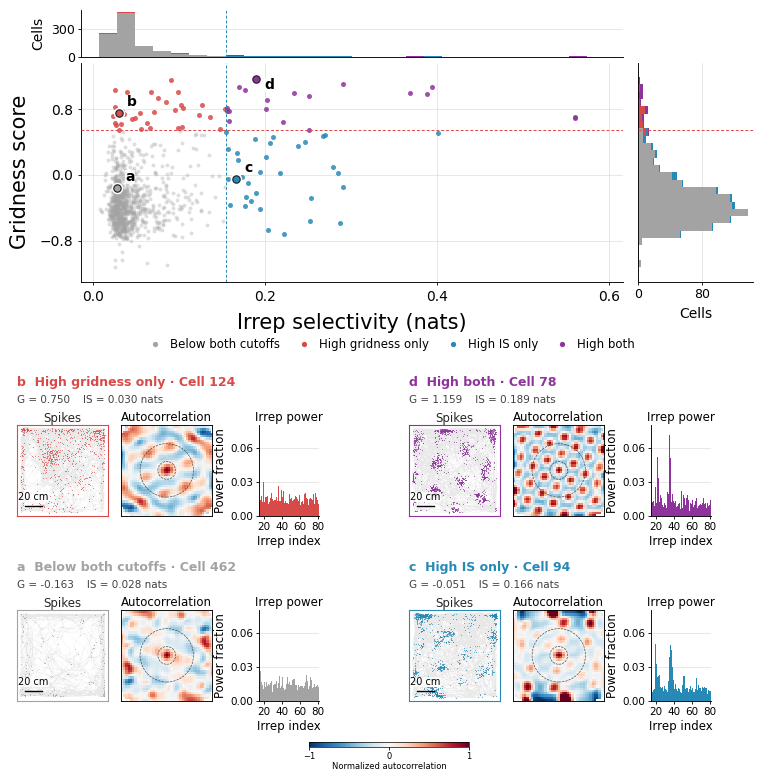

Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/panels/figure8_scatter_m6.pdf
Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/panels/figure8_example_a_cell_462_m6.pdf
Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/panels/figure8_example_b_cell_124_m6.pdf
Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/panels/figure8_example_c_cell_94_m6.pdf
Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/panels/figure8_example_d_cell_78_m6.pdf
Exported 5 component PDFs to /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/panels


In [59]:
fig = plot_main_figure()
plt.show()
plt.close(fig)

# Exactly one joint scatter PDF and one complete PDF row for each main example.
component_manifest = export_main_components()

## 8. Optional appendix galleries

These large overview sweeps are **off by default**. Set `EXPORT_OVERVIEW_GALLERIES=True` to export the 4 × 10 overview and the two 4 × 5 pages as PDFs. The compact four-cell diagnostic pages below are always exported. Groups with fewer available cells show the available cells only.

In [47]:
# Optional overview galleries (off by default).
if EXPORT_OVERVIEW_GALLERIES:
    fig = plot_gallery(columns=APPENDIX_CELLS_PER_GROUP)
    plt.show()
    plt.close(fig)
    if APPENDIX_CELLS_PER_GROUP > 5:
        for start in range(0, APPENDIX_CELLS_PER_GROUP, 5):
            fig = plot_gallery(columns=min(5, APPENDIX_CELLS_PER_GROUP-start), offset=start,
                               stem=f"appendix_spike_gallery_page_{start//5+1}_m6")
            plt.close(fig)

### Rate maps, autocorrelograms, and spectra

Each diagnostic row shows a cell's spike map, the exact spatial rate map used for gridness, its
autocorrelogram (including the fixed scoring annulus), and the IS power distribution. Autocorrelation
colours saturate at −1 and +1; this normalization is not a lagwise Pearson correlation and can exceed
that display range. Rate-map colour scales are per cell. **All power spectra on these pages share
one y-axis range across every displayed cell in all four groups.** The range is computed before
plotting and used for both display and PDF export. These pages use the first four cells in each
gallery row by default. Filled-step spectra preserve every retained coefficient and remove the
thin gaps that can look striped at reduced display sizes.

Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/appendix/appendix_details_neither_m6.pdf


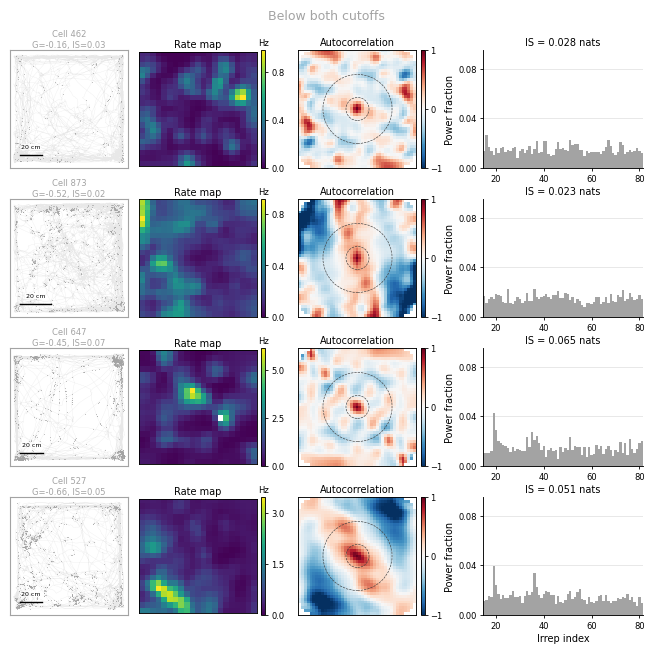

Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/appendix/appendix_details_gridness_only_m6.pdf


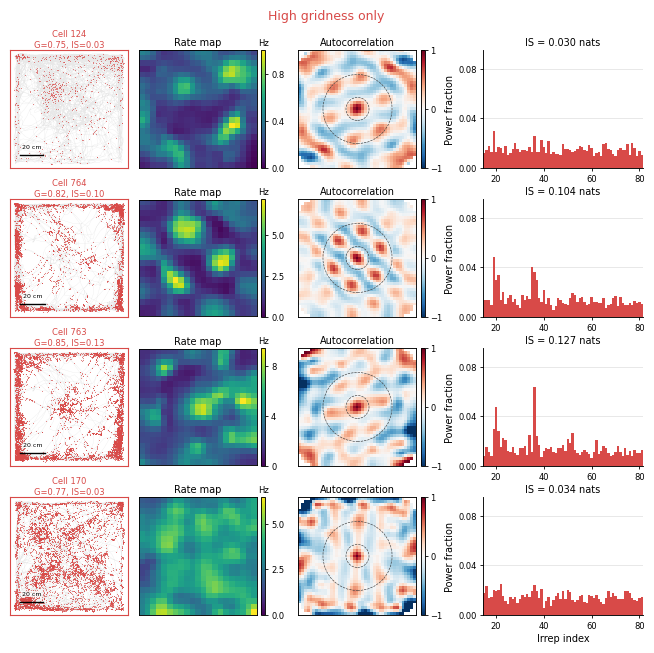

Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/appendix/appendix_details_irrep_only_m6.pdf


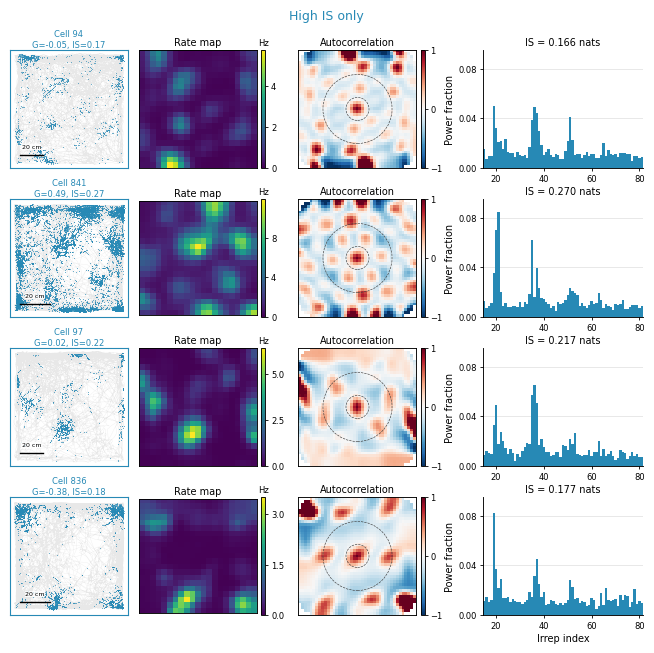

Saved: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8/appendix/appendix_details_both_m6.pdf


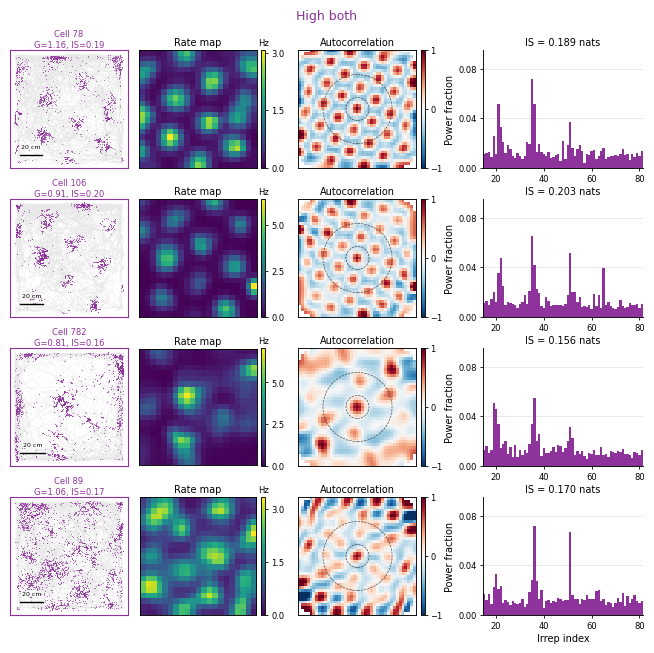

Exact highlighted coordinates (x = IS, y = gridness):
  a: cell 462, IS=0.027755, G=-0.163110, neither
  b: cell 124, IS=0.030245, G=0.750101, gridness_only
  c: cell 94, IS=0.166288, G=-0.050502, irrep_only
  d: cell 78, IS=0.189439, G=1.159226, both
Saved all figures and tables to /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/neural data/Giocomo/figure8


In [48]:
# Shared across all displayed cells in all four groups, before PDF export.
DETAIL_POWER_YLIM = appendix_power_ylim()
for key, _, _ in GROUPS:
    fig = plot_cell_details(key, appendix_selection[key][:DETAIL_CELLS_PER_GROUP],
                           power_ylim=DETAIL_POWER_YLIM)
    if fig is not None:
        plt.show()
        plt.close(fig)

print("Exact highlighted coordinates (x = IS, y = gridness):")
for row in examples:
    print(f"  {row['example_label']}: cell {row['cell_index']}, "
          f"IS={row['irrep_selectivity']:.6f}, G={row['gridness']:.6f}, {row['quadrant']}")
print("Saved all figures and tables to", OUTPUT_DIR)

## 9. Generate the figure captions and appendix methods

The next cell writes complete LaTeX fragments to `figure8/data`, using this run's actual cell count,
thresholds, retained-irrep set, and configuration. The accompanying standalone `.tex` draft uses the
same default methods but deliberately omits numbers that require the missing recording to be rerun.

The associated paper is [Mallory, Hardcastle et al. (2021), *Mouse entorhinal cortex encodes a diverse
repertoire of self-motion signals*](https://doi.org/10.1038/s41467-021-20936-8).
The [Giocomo lab data page](https://giocomolab.weebly.com/data-code-methods.html) links its deposits.
The LaTeX citation key is `mallory2021mouse`; adjust it to match your bibliography.

The methods explicitly distinguish movement direction from head direction, spell out the group
coordinate assignment and the index restriction, and treat percentile cutoffs as descriptive.

In [49]:
def manuscript_fragments():
    n_cells = len(comparison)
    k = int(included.sum())
    latex_filename = FILE_PATH.name.replace("_", r"\_")
    preferred_ids = ", ".join(str(PREFERRED_EXAMPLES.get(key)) for key, _, _ in GROUPS)
    selected_indices = np.flatnonzero(included)
    selected_dimensions = sorted({meta["dimension"] for meta, use in
                                  zip(transform.metadata, included) if use})
    dimension_text = (rf"All retained irreps have dimension ${selected_dimensions[0]}$. "
                      if len(selected_dimensions) == 1 else
                      "Retained irrep dimensions are recorded in the catalogue. ")
    if CFG.irrep_selection == "legacy_index":
        selection_text = (
            rf"We retain zero-based irrep indices ${selected_indices[0]}$--${selected_indices[-1]}$ "
            rf"in the supplied implementation, giving $K={k}$ included irreps. " +
            dimension_text +
            "The cutoff is an index-based restriction, not a radial spatial-frequency cutoff. "
            "The exported irrep catalogue records "
            "the translation-frequency orbit and stabilizer character of every included irrep. "
        )
    else:
        selection_text = (rf"We include all $K={k}$ nontrivial irreps, excluding only "
                          "the constant representation. ")
    caption = rf"""\caption{{\textbf{{Irrep selectivity and gridness in freely moving MEC recordings.}}
Each point represents one neuron ($N={n_cells}$); stacked marginal histograms show cell counts.
Irrep selectivity is on the horizontal axis and gridness score on the vertical axis.
Irrep selectivity is computed from position--movement-direction tuning on
$C_{{{CFG.n_space}}}^2\rtimes C_6$ and expressed in nats.
Dashed lines indicate the {PERCENTILE:g}th percentile of each score.
Colours distinguish cells below both cutoffs (grey), above only the gridness cutoff
(red), above only the irrep-selectivity cutoff (blue), or above both (purple).
Black-outlined points labelled a--d identify the corresponding examples below,
arranged in the same positions as the four scatter quadrants.
Each example shows the trajectory (grey) and spike locations (matching colour),
the spatial autocorrelogram used for gridness, and the normalized irrep-power distribution.
Dashed circles mark the gridness annulus; autocorrelation colours saturate at $-1$ and $1$.
Spectra show all $K={k}$ retained irreps (indices
${selected_indices[0]}$--${selected_indices[-1]}$), normalized to unit total power,
with a common vertical scale across the four examples.
The spectra are computed from unsmoothed position--movement-direction tuning, independently
of the spatial autocorrelograms. These percentile cutoffs are descriptive,
not significance thresholds. Scale bars are labelled.}}
\label{{fig:irrep-selectivity}}
"""
    appendix_caption = r"""\caption{\textbf{Additional examples across the gridness--irrep-selectivity distribution.}
Rows correspond to cells below both percentile cutoffs, above only the gridness
cutoff, above only the irrep-selectivity cutoff, and above both, respectively.
The first column contains the main-figure example when available; remaining cells
are sampled without replacement within each group using random seed 0.
Grey lines show trajectories and coloured points show spike locations.
Titles report the zero-based cell index, gridness (G), and irrep selectivity (IS, nats).
The two five-column pages partition the same examples as the ten-column overview.
Scale bars are labelled.}
""".replace("random seed 0", f"random seed {APPENDIX_SEED}")
    detail_caption = r"""\caption{\textbf{Tuning and irrep spectra of example neurons.}
Each row shows one cell's trajectory and spike locations, spatial firing-rate map,
spatial autocorrelogram, and normalized power over the included irreps.
Rate maps and autocorrelograms are the same arrays used to compute gridness.
Dashed circles delimit the scoring annulus; autocorrelogram colours are displayed
on a common range from $-1$ to $1$, with values outside that range saturated.
The irrep spectrum is calculated from the unsmoothed position--movement-direction
tuning tensor, rather than from the spatial autocorrelogram.
Filled steps show every included irrep without smoothing or gaps between adjacent indices.
Firing-rate colour scales are in Hz and vary across cells. All displayed appendix
spectra share one vertical scale across cells and all four groups.}
"""
    main_text = rf"""% Replace the manuscript's 'heading bins' description with:
For planar navigation, we estimate firing rates in ${CFG.n_space}\times{CFG.n_space}$ position bins
and six $60^\circ$ bins of movement direction, inferred from the animal's trajectory
at speeds of at least ${CFG.speed_threshold_cm_s:g}\,\mathrm{{cm\,s^{{-1}}}}$. We interpret the resulting response
tensor as a signal on $C_{{{CFG.n_space}}}^2\rtimes C_6$ under the coordinate assignment specified
in the appendix, and normalize the Fourier power over the included irreps.
"""
    methods = rf"""\subsection{{Irrep selectivity in freely moving recordings}}
\label{{app:irrep-selectivity-data}}

\paragraph{{Data and analysis set.}}
We analyze medial entorhinal cortex recordings from freely moving mice associated
with \citet{{mallory2021mouse}}, using the Giocomo lab file
\texttt{{{latex_filename}}}.
For each cell, we use recording times and spike times in seconds and body position
in centimetres. The analysis uses movement direction estimated from position,
not the recorded azimuthal head-direction channel. Cell labels are zero-based
indices in the input file; the exported tables also retain the source cell and
animal identifiers. We include all cells with finite values for both scores
($N={n_cells}$ in the current run). Cells excluded for missing fields, invalid tracking,
insufficient occupancy, or undefined scores are recorded with an explicit reason.

\paragraph{{Temporal alignment and occupancy.}}
Recording timestamps must be finite and strictly increasing. Position samples
with nonfinite coordinates are excluded. Each tracking sample is assigned half
of each adjacent valid sampling interval; the first and last samples receive
only their inward half-interval. Intervals longer than {CFG.max_gap_factor:g} times the
median sampling interval are treated as gaps and contribute no dwell time.
Spikes are assigned to the nearest sample on the original tracking timeline,
with midpoint ties assigned to the earlier sample. Spikes outside the recorded
time range, inside tracking gaps, or assigned to invalid position samples are
discarded. Temporal alignment is performed before applying a movement mask,
so spikes during excluded behaviour cannot be reassigned to later eligible samples.

\paragraph{{Spatial rate maps and gridness.}}
For each cell, the observed position range is divided into
${CFG.grid_n_bins}\times{CFG.grid_n_bins}$ rectangular bins. We accumulate spike counts
and dwell time over all valid position samples, without a speed cutoff for gridness.
Counts and occupancy are separately smoothed with a Gaussian kernel of standard
deviation {CFG.grid_smooth_sigma:g} spatial bin, using reflected boundaries, before
taking their ratio. Bins with smoothed occupancy below ${CFG.min_occ_seconds:g}$ s
are masked. These same rate maps are displayed in the diagnostic figures.

Let $r(x)$ denote a rate map, $M(x)$ its validity mask, and $\mu$ the unweighted
mean over valid bins. We compute the linear, nonperiodic spatial autocovariance
\[
C(\ell)=\frac{{\sum_x M(x)M(x+\ell)[r(x)-\mu][r(x+\ell)-\mu]}}
                   {{\sum_x M(x)M(x+\ell)}}.
\]
Lags with fewer than {CFG.min_autocorr_overlap} overlapping valid bins are masked,
and the autocorrelogram is normalized by $C(0)$. Pearson correlations
$c_\alpha$ are calculated between this autocorrelogram and its rotations by
$\alpha\in\{{30^\circ,60^\circ,90^\circ,120^\circ,150^\circ\}}$,
using bilinear interpolation and only valid pixels in a fixed annulus.
Its inner and outer radii are {CFG.grid_annulus_inner:g} and {CFG.grid_annulus_outer:g}
times the distance from the origin to the nearest edge of the autocorrelogram.
Each correlation requires at least {CFG.min_rotation_pixels} valid pixels and
nonzero variance in both arrays. Gridness is
\[
\mathrm{{G}}=\min(c_{{60^\circ}},c_{{120^\circ}})
             -\max(c_{{30^\circ}},c_{{90^\circ}},c_{{150^\circ}}).
\]
The annulus is fixed rather than optimized separately for each cell.

\paragraph{{Position--movement-direction tuning.}}
Velocity is estimated by central differences,
$v_i=(z_{{i+1}}-z_{{i-1}})/(t_{{i+1}}-t_{{i-1}})$, where $z_i=(x_i,y_i)$.
Both neighbouring intervals and all three position samples must be valid.
We retain samples with $\lVert v_i\rVert\geq {CFG.speed_threshold_cm_s:g}\,
\mathrm{{cm\,s^{{-1}}}}$ and use
$\phi_i=\operatorname{{atan2}}(v_{{i,y}},v_{{i,x}})\bmod 2\pi$ as movement direction.
The position range of these retained samples is divided into
${CFG.n_space}\times{CFG.n_space}$ bins, and direction into six equal bins on
$[0,2\pi)$. The same movement mask is applied to spikes and occupancy.
In each position--direction bin, the unsmoothed rate is the spike count divided
by dwell time; bins with occupancy below ${CFG.min_occ_seconds:g}$ s are unobserved.
We subtract the unweighted mean rate over observed bins and set unobserved
entries to zero after centering. Thus missing bins are filled with the observed
mean before centering. No spatial or angular smoothing and no autocorrelation
transform is applied to the signal used for irrep selectivity.

\paragraph{{Group coordinates and Fourier power.}}
We assign the rectangular spatial-bin indices $(a,b)$ and direction-bin index $k$
to elements of $G=C_{{{CFG.n_space}}}^2\rtimes C_6$, which has
${CFG.n_space**2*CFG.m_dir}$ elements and ${len(transform.metadata)} complex irreps, with rotation action
\[
A=\begin{{pmatrix}}0&-1\\1&1\end{{pmatrix}},\qquad
(a,b,k)(a',b',k')=((a,b)+A^k(a',b'),\,k+k'),
\]
where translation coordinates are taken modulo ${CFG.n_space}$ and direction
indices modulo six. Group elements are stored in the order
$k{CFG.n_space}^2+a{CFG.n_space}+b$.
This assignment specifies a discrete coordinate convention: $A$ represents a
$60^\circ$ rotation in a triangular-lattice basis, whereas the recorded spatial
bins are rectangular. The present assignment therefore does not implement exact
Euclidean $60^\circ$ rotations of the recorded arena. The score is interpreted
for this specified discretization and coordinate assignment.

For the centered signal $f:G\to\mathbb{{R}}$, the Fourier coefficients and powers are
\[
\widehat f(\rho)=\sum_{{g\in G}}f(g)\rho(g)^\dagger,\qquad
P_\rho=\frac{{d_\rho}}{{|G|}}\lVert\widehat f(\rho)\rVert_F^2.
\]
The implementation evaluates the same transform using two-dimensional spatial
FFTs and the induced-representation coefficients supplied by the group code.
It verifies Parseval's identity $\sum_\rho P_\rho=\sum_g|f(g)|^2$ for every cell.
Irreps are kept as separate blocks, without merging conjugate pairs.
{selection_text}
Writing $\mathcal{{I}}$ for the retained set, we define
\[
p_\rho=\frac{{P_\rho}}{{\sum_{{\sigma\in\mathcal{{I}}}}P_\sigma}},\qquad
\mathrm{{IS}}=\log K+\sum_{{\rho\in\mathcal{{I}}}}p_\rho\log p_\rho,
\quad K=|\mathcal{{I}}|,
\]
with $0\log0=0$. Natural logarithms give IS in nats. Its theoretical range is
$[0,\log K]$; it is not rescaled to $[0,1]$. The retained-power fraction and a
comparison score using all nontrivial irreps are exported for each cell.

\paragraph{{Comparison and example selection.}}
Thresholds are the {PERCENTILE:g}th percentiles of each score among cells with
both scores, computed with linear percentile interpolation. Values equal to
a threshold are assigned to the high group. The current thresholds are
${gridness_threshold:.6f}$ for gridness and ${is_threshold:.6f}$ nats for IS.
These are descriptive cutoffs, not significance thresholds from a null model.
Marginal histograms use common edges across groups and stack their counts.
The scatter displays IS horizontally and gridness vertically; its vertical
cutoff line is therefore the IS threshold and its horizontal line the gridness threshold.
The highlighted scatter coordinates are retrieved by the same cell index used
to render each example, rather than placed manually.
For each main-figure example, the autocorrelogram is the cached array used for
gridness, and the power distribution contains every retained irrep in implementation
order. Filled steps remove display gaps between adjacent indices without smoothing,
reordering, or dropping any retained coefficient. The main spectra use one common
vertical scale and each is normalized to unit total retained power. Autocorrelation
colours share the range $[-1,1]$, with values outside this range saturated.
Figures are exported as PDF. Separate main-figure exports comprise the joint
scatter with its marginals and legend, and one complete diagnostic row per
example. A component manifest records their identities, paths, and analysis run ID.

The configured preferred cell indices are {preferred_ids}
for the below-both, high-gridness-only, high-IS-only, and high-both groups,
respectively. If a preferred cell is unavailable or changes group, we select the
cell nearest the within-group coordinatewise median score pair, after scaling
each score by its standard deviation over the full comparison set. Ties are
resolved by the smallest cell index. The exact selection and its reason are
exported. Appendix galleries begin with the main example and add up to
{APPENDIX_CELLS_PER_GROUP-1} cells sampled without replacement from each group
using random seed {APPENDIX_SEED}. The diagnostic pages use the first
{DETAIL_CELLS_PER_GROUP} cells in each gallery row. Trajectories may be subsampled
for rendering; all valid spike locations are shown, and all analysis uses the
full time series.
All displayed appendix power spectra share a common vertical range computed
from the retained power fractions across the selected cells in all four groups;
the range is applied before saving each figure. This makes power concentrations
directly comparable between groups. The main examples likewise share one range
across their four spectra and corresponding standalone row exports.

\paragraph{{Interpretation and reproducibility.}}
Scores depend on spatial binning, the coordinate assignment, sampled support,
and the included irreps. Filling unobserved bins and finite sampling can introduce
spectral structure; high IS alone does not establish path-integration function.
The analysis exports all scores, exclusions, retained irrep identities, occupancy
coverage, example indices, thresholds, source-file signature, group-code hashes,
software versions, and analysis parameters. Per-cell arrays are cached in a
visible output directory keyed by the data signature and analysis configuration.
"""
    return {"figure8_caption.tex": caption, "appendix_gallery_caption.tex": appendix_caption,
            "appendix_details_caption.tex": detail_caption,
            "main_text_correction.tex": main_text, "appendix_irrep_selectivity_methods.tex": methods}

for name, content in manuscript_fragments().items():
    (DATA_OUT/name).write_text(content)

display(Markdown("**Caption and methods exported.** The LaTeX fragments in `figure8/data` "
                 "contain this run's actual cell count, thresholds, and analysis settings."))

**Caption and methods exported.** The LaTeX fragments in `figure8/data` contain this run's actual cell count, thresholds, and analysis settings.

### Read the generated caption

It is also in `figure8/data/figure8_caption.tex`.

In [50]:
print(manuscript_fragments()["figure8_caption.tex"])

\caption{\textbf{Irrep selectivity and gridness in freely moving MEC recordings.}
Each point represents one neuron ($N=1021$); stacked marginal histograms show cell counts.
Irrep selectivity is on the horizontal axis and gridness score on the vertical axis.
Irrep selectivity is computed from position--movement-direction tuning on
$C_{21}^2\rtimes C_6$ and expressed in nats.
Dashed lines indicate the 95th percentile of each score.
Colours distinguish cells below both cutoffs (grey), above only the gridness cutoff
(red), above only the irrep-selectivity cutoff (blue), or above both (purple).
Black-outlined points labelled a--d identify the corresponding examples below,
arranged in the same positions as the four scatter quadrants.
Each example shows the trajectory (grey) and spike locations (matching colour),
the spatial autocorrelogram used for gridness, and the normalized irrep-power distribution.
Dashed circles mark the gridness annulus; autocorrelation colours saturate at $-1$ and $1$

## 10. Inspect another cell or change the examples

To choose different main examples, edit `PREFERRED_EXAMPLES` and rerun the selection/plotting cells.
The cached analysis is reused. To inspect a single cell without rebuilding the main figure:

In [51]:
# cell_index = 101
# if cell_index in score_lookup:
#     key = score_lookup[cell_index]['quadrant']
#     fig = plot_cell_details(key, [cell_index], stem=f'cell_{cell_index}_diagnostic_m6')
#     plt.show()
#     plt.close(fig)

# When completely finished with this kernel:
# if data_handle is not None:
#     data_handle.close()

### Output index

| Location under `figure8/` | Contents |
|---|---|
| `figure8_irrep_selectivity_m6.pdf` | Full-width main figure: large scatter above a 2 × 2 block of examples |
| `panels/figure8_scatter_m6.pdf` | Joint scatter with marginals and legend |
| `panels/figure8_example_<letter>_cell_<index>_m6.pdf` | One complete row per main cell: spikes, autocorrelation, spectrum |
| `appendix/appendix_details_<group>_m6.pdf` | Compact diagnostic pages with a common power scale across groups |
| `appendix/appendix_spike_gallery*.pdf` | Optional overview galleries, only when enabled |
| `data/scores.csv` | All successfully computed cell metrics |
| `data/comparison.csv` | Cells with both scores and their actual group |
| `data/example_cells.csv`, `appendix_cells.csv` | Exact selected indices and selection reasons |
| `data/excluded_cells.csv` | Explicit exclusions |
| `data/irrep_catalogue.csv` | Included irreps and translation-frequency orbits |
| `data/figure8_components.csv` | Component paths, example identities, and run ID |
| `data/example_irrep_power.csv` | All main-example powers, retained fractions, and inclusion flags |
| `data/run_summary.json` | Parameters, thresholds, counts, provenance, versions |
| `data/*.tex` | Main caption, appendix captions, methods, main-text correction |
| `cache/<run_id>/` | Reusable numerical arrays and cache manifest |

**Validation performed for this revision:** exact Fourier-power comparison with the supplied
implementation at $n=3,4,5,20,21$; Parseval checks; temporal-gap and slow-spike regression checks;
classic MATLAB and both HDF5 cell layouts; a 100-cell synthetic end-to-end fixture; cache agreement;
and visual layout inspection. Synthetic checks are not experimental findings, and their values are
not embedded here. The real 6.37 GB recording still needs to be run on your machine.